In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor

## Введение в анализ данных

In [3]:
df = pd.read_json("./data/train.json")
df

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,92bbbf38baadfde0576fc496bd41749c,2016-04-05 03:58:33,There is 700 square feet of recently renovated...,W 171 Street,"[Elevator, Dishwasher, Hardwood Floors]",40.8433,6824800,-73.9396,a61e21da3ba18c7a3d54cfdcc247e1f8,[https://photos.renthop.com/2/6824800_0682be16...,2800,620 W 171 Street,low
124002,1.0,2,5565db9b7cba3603834c4aa6f2950960,2016-04-02 02:25:31,"2 bedroom apartment with updated kitchen, rece...",Broadway,"[Common Outdoor Space, Cats Allowed, Dogs Allo...",40.8198,6813268,-73.9578,8f90e5e10e8a2d7cf997f016d89230eb,[https://photos.renthop.com/2/6813268_1e6fcc32...,2395,3333 Broadway,medium
124004,1.0,1,67997a128056ee1ed7d046bbb856e3c7,2016-04-26 05:42:03,No Brokers Fee * Never Lived 1 Bedroom 1 Bathr...,210 Brighton 15th St,"[Dining Room, Elevator, Pre-War, Laundry in Bu...",40.5765,6927093,-73.9554,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/6927093_93a52104...,1850,210 Brighton 15th St,medium
124008,1.0,2,3c0574a740154806c18bdf1fddd3d966,2016-04-19 02:47:33,Wonderful Bright Chelsea 2 Bedroom apartment o...,West 21st Street,"[Pre-War, Laundry in Unit, Dishwasher, No Fee,...",40.7448,6892816,-74.0017,c3cd45f4381ac371507090e9ffabea80,[https://photos.renthop.com/2/6892816_1a8d087a...,4195,350 West 21st Street,medium


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


целевой столбец - price

In [6]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [7]:
df.corr(numeric_only=True)

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


нет пустых столбцов

In [9]:
df = df[["bathrooms", "bedrooms", "interest_level", "price"]]
df

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795
...,...,...,...,...
124000,1.0,3,low,2800
124002,1.0,2,medium,2395
124004,1.0,1,medium,1850
124008,1.0,2,medium,4195


## Статистический анализ данных

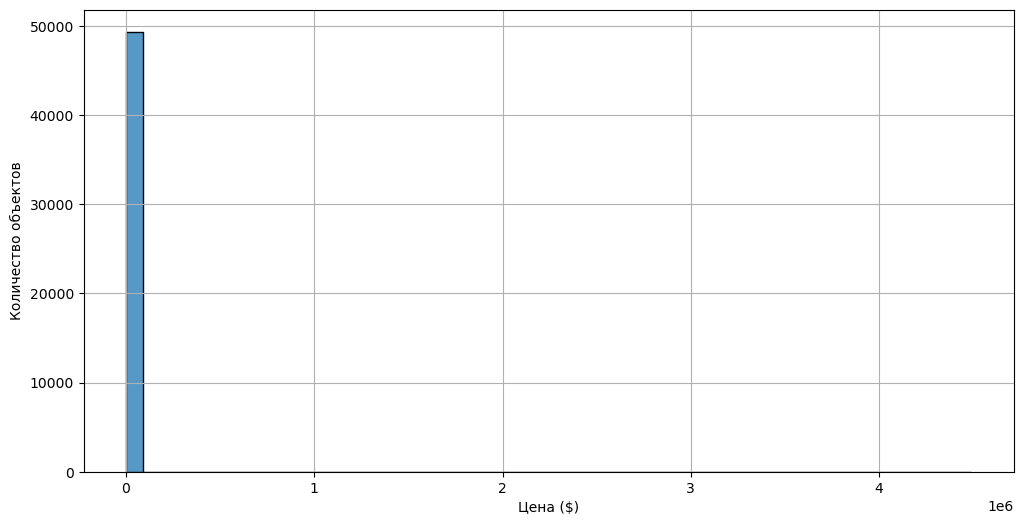

In [11]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df, x='price', bins=50)
plt.xlabel('Цена ($)')
plt.ylabel('Количество объектов')
plt.grid(True)
plt.show()



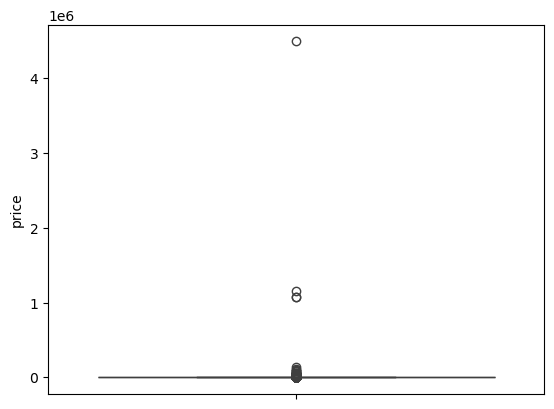

In [12]:
sns.boxplot(data=df, y="price")
plt.show()

In [13]:
q_low = df["price"].quantile(0.01)
q_high = df["price"].quantile(0.99)
df = df[(q_low <= df["price"]) & (df["price"] <= q_high)]

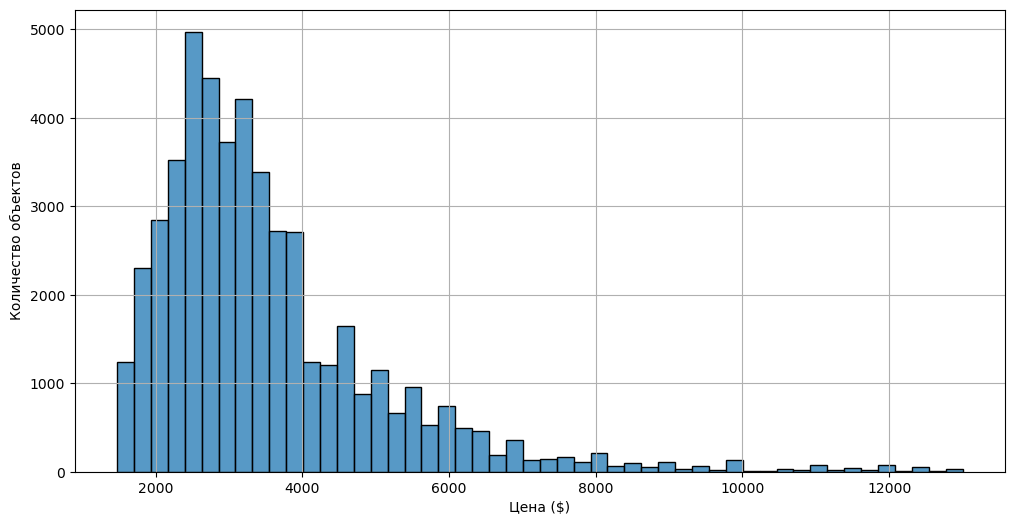

In [14]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df, x='price', bins=50)
plt.xlabel('Цена ($)')
plt.ylabel('Количество объектов')
plt.grid(True)
plt.show()


In [15]:
df["interest_level"].info()

<class 'pandas.core.series.Series'>
Index: 48379 entries, 4 to 124009
Series name: interest_level
Non-Null Count  Dtype 
--------------  ----- 
48379 non-null  object
dtypes: object(1)
memory usage: 755.9+ KB


In [16]:
df["interest_level"]

4         medium
6            low
9         medium
10        medium
15           low
           ...  
124000       low
124002    medium
124004    medium
124008    medium
124009      high
Name: interest_level, Length: 48379, dtype: object

In [17]:
df.groupby("interest_level").size()

interest_level
high       3566
low       33697
medium    11116
dtype: int64

In [18]:
mapping = {'low': 0, 'medium': 1, 'high': 2}
df['interest_level'] = df['interest_level'].map(mapping)

/tmp/ipykernel_41971/2345711659.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['interest_level'] = df['interest_level'].map(mapping)


In [19]:
df

,bathrooms,bedrooms,interest_level,price
4,1.0,1,1,2400
6,1.0,2,0,3800
9,1.0,2,1,3495
10,1.5,3,1,3000
15,1.0,0,0,2795
...,...,...,...,...
124000,1.0,3,0,2800
124002,1.0,2,1,2395
124004,1.0,1,1,1850
124008,1.0,2,1,4195


In [20]:
df.corr(numeric_only=True)

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517574,-0.063635,0.671943
bedrooms,0.517574,1.000000,0.050654,0.545948
interest_level,-0.063635,0.050654,1.000000,-0.200111
price,0.671943,0.545948,-0.200111,1.000000


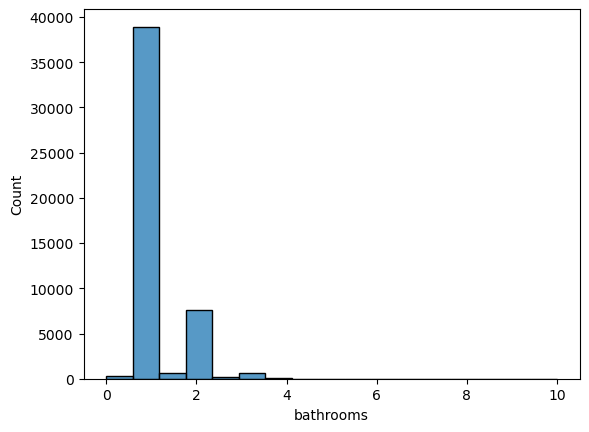

In [21]:
sns.histplot(data=df, x="bathrooms")
plt.show()

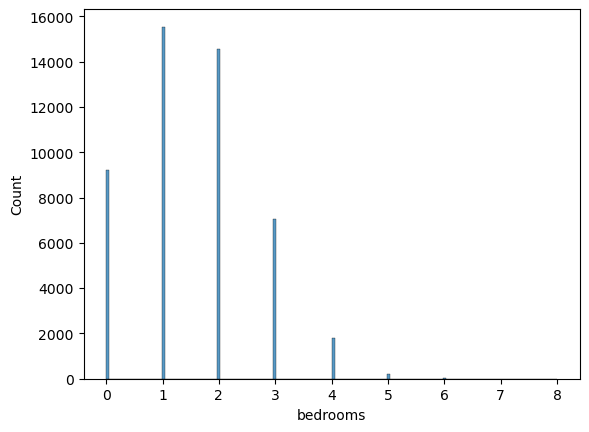

In [22]:
sns.histplot(data=df, x="bedrooms")
plt.show()

выбросов нет

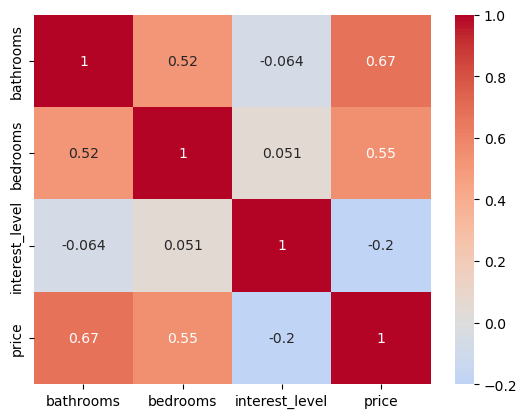

In [24]:
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            center=0)
plt.show()

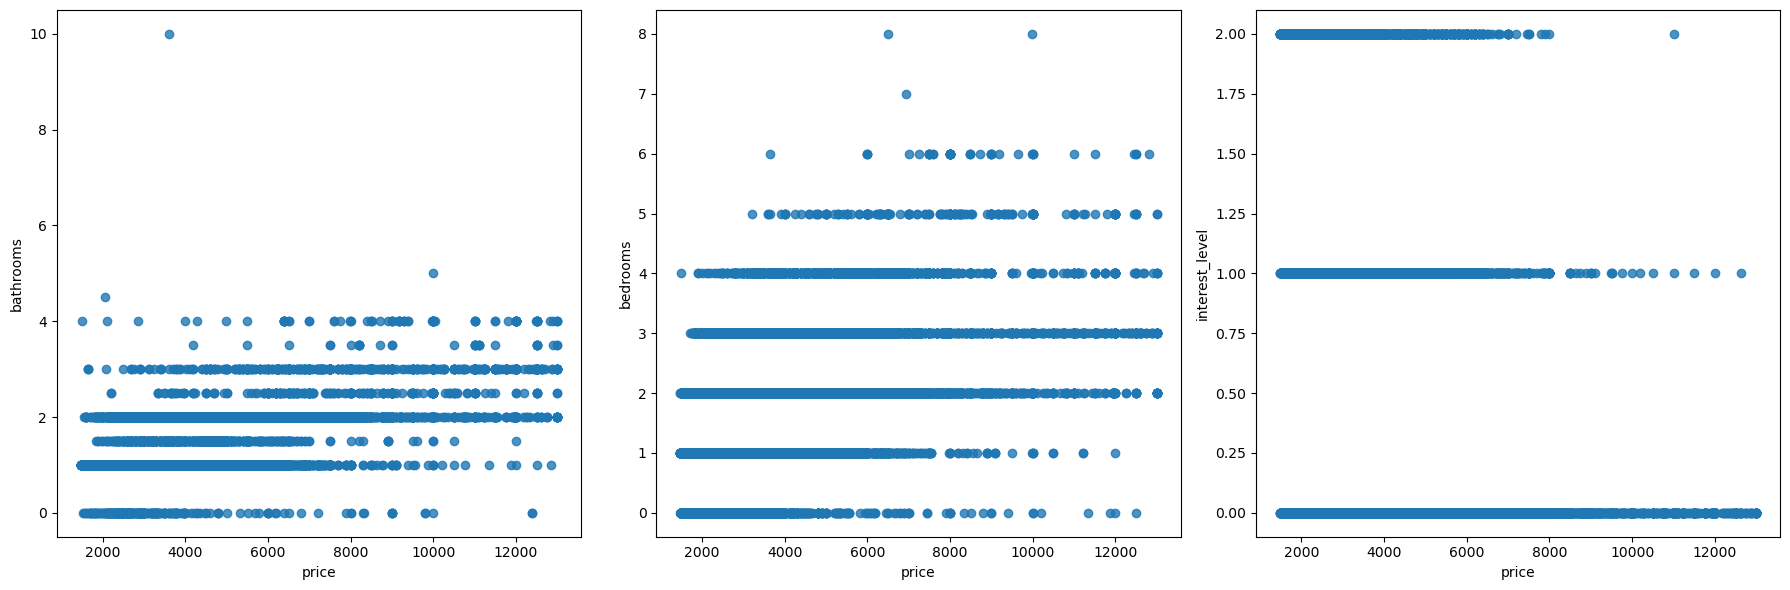

In [25]:
features = ["bathrooms", "bedrooms", "interest_level"]  


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feature in enumerate(features):
    sns.regplot(x='price', y=feature, data=df, ax=axes[i], fit_reg=False)

plt.tight_layout()
plt.show()

## Создание функций



In [27]:
df_copy = df.assign(
    bathrooms_squared=df["bathrooms"]**2,
    bedrooms_squared=df["bedrooms"]**2,
    interest_level_squared=df["interest_level"]**2  # используем закодированную версию
)

In [28]:
df_copy.drop(["bathrooms","interest_level","bedrooms"], axis=1, inplace=True)

In [29]:
df_copy

,price,bathrooms_squared,bedrooms_squared,interest_level_squared
4,2400,1.00,1,1
6,3800,1.00,4,0
9,3495,1.00,4,1
10,3000,2.25,9,1
15,2795,1.00,0,0
...,...,...,...,...
124000,2800,1.00,9,0
124002,2395,1.00,4,1
124004,1850,1.00,1,1
124008,4195,1.00,4,1


In [30]:
df_copy.corr()

,price,bathrooms_squared,bedrooms_squared,interest_level_squared
price,1.000000,0.648486,0.543406,-0.182672
bathrooms_squared,0.648486,1.000000,0.522227,-0.062240
bedrooms_squared,0.543406,0.522227,1.000000,0.035718
interest_level_squared,-0.182672,-0.062240,0.035718,1.000000


In [31]:
df.corr()

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517574,-0.063635,0.671943
bedrooms,0.517574,1.000000,0.050654,0.545948
interest_level,-0.063635,0.050654,1.000000,-0.200111
price,0.671943,0.545948,-0.200111,1.000000


In [32]:
del(df_copy)

In [33]:
poly = PolynomialFeatures(degree=10)
poly

PolynomialFeatures(degree=10)

In [34]:
df_test = pd.read_json("./data/test.json")

In [35]:
df_test = df_test[["bathrooms", "bedrooms", "price"]]
df_test

,bathrooms,bedrooms,price
0,1.0,1,2950
1,1.0,2,2850
2,1.0,0,2295
3,1.0,2,2900
5,1.0,1,3254
...,...,...,...
124003,1.0,1,1700
124005,1.0,2,4195
124006,1.0,0,2400
124007,2.0,2,6895


In [36]:
df.drop("interest_level",axis=1, inplace=True)

/tmp/ipykernel_41971/1771197463.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop("interest_level",axis=1, inplace=True)


In [37]:
poly.fit_transform(df)

array([[1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        1.10075314e+27, 2.64180754e+30, 6.34033810e+33],
       [1.00000000e+00, 1.00000000e+00, 2.00000000e+00, ...,
        1.73911686e+29, 3.30432203e+32, 6.27821185e+35],
       [1.00000000e+00, 1.00000000e+00, 2.00000000e+00, ...,
        8.90507193e+28, 1.55616132e+32, 2.71939191e+35],
       ...,
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        1.37206229e+26, 2.53831523e+29, 4.69588318e+32],
       [1.00000000e+00, 1.00000000e+00, 2.00000000e+00, ...,
        3.83632783e+29, 8.04669763e+32, 1.68779483e+36],
       [1.00000000e+00, 1.00000000e+00, 3.00000000e+00, ...,
        1.01342745e+30, 1.44582316e+33, 2.06270770e+36]])

In [38]:
X_train = df[["bedrooms", "bathrooms"]]
y_train = df["price"]
X_test = df_test[["bedrooms", "bathrooms"]]
y_test = df_test["price"]

In [39]:
X_train = poly.fit_transform(X_train)
X_train = pd.DataFrame(X_train, 
                           columns=poly.get_feature_names_out(["bedrooms", "bathrooms"]))

X_test = poly.transform(X_test)
X_test = pd.DataFrame(X_test, 
                          columns=poly.get_feature_names_out(["bedrooms", "bathrooms"]))

In [40]:
X_train

,1,bedrooms,bathrooms,bedrooms^2,bedrooms bathrooms,bathrooms^2,bedrooms^3,bedrooms^2 bathrooms,bedrooms bathrooms^2,bathrooms^3,...,bedrooms^9 bathrooms,bedrooms^8 bathrooms^2,bedrooms^7 bathrooms^3,bedrooms^6 bathrooms^4,bedrooms^5 bathrooms^5,bedrooms^4 bathrooms^6,bedrooms^3 bathrooms^7,bedrooms^2 bathrooms^8,bedrooms bathrooms^9,bathrooms^10
0,1.0,1.0,1.0,1.0,1.0,1.00,1.0,1.0,1.00,1.000,...,1.0,1.00,1.000,1.0000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
1,1.0,2.0,1.0,4.0,2.0,1.00,8.0,4.0,2.00,1.000,...,512.0,256.00,128.000,64.0000,32.00000,16.000000,8.000000,4.000000,2.000000,1.000000
2,1.0,2.0,1.0,4.0,2.0,1.00,8.0,4.0,2.00,1.000,...,512.0,256.00,128.000,64.0000,32.00000,16.000000,8.000000,4.000000,2.000000,1.000000
3,1.0,3.0,1.5,9.0,4.5,2.25,27.0,13.5,6.75,3.375,...,29524.5,14762.25,7381.125,3690.5625,1845.28125,922.640625,461.320312,230.660156,115.330078,57.665039
4,1.0,0.0,1.0,0.0,0.0,1.00,0.0,0.0,0.00,1.000,...,0.0,0.00,0.000,0.0000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48374,1.0,3.0,1.0,9.0,3.0,1.00,27.0,9.0,3.00,1.000,...,19683.0,6561.00,2187.000,729.0000,243.00000,81.000000,27.000000,9.000000,3.000000,1.000000
48375,1.0,2.0,1.0,4.0,2.0,1.00,8.0,4.0,2.00,1.000,...,512.0,256.00,128.000,64.0000,32.00000,16.000000,8.000000,4.000000,2.000000,1.000000
48376,1.0,1.0,1.0,1.0,1.0,1.00,1.0,1.0,1.00,1.000,...,1.0,1.00,1.000,1.0000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
48377,1.0,2.0,1.0,4.0,2.0,1.00,8.0,4.0,2.00,1.000,...,512.0,256.00,128.000,64.0000,32.00000,16.000000,8.000000,4.000000,2.000000,1.000000


In [41]:
result_MAE = pd.DataFrame(columns=["model","train","test"])
result_RMSE=pd.DataFrame(columns=["model","train","test"])
result_MAE

,model,train,test


In [42]:
model_linear = LinearRegression()

In [43]:
def push(name, models, X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test,result_MAE=result_MAE, result_RMSE=result_RMSE):
    
    model_linear.fit(X=X_train,y=y_train)
    
    y_train_predict = model_linear.predict(X_train)
    y_test_predict = model_linear.predict(X_test)
    
    mae_train = mean_absolute_error(y_train, y_train_predict)
    mae_test = mean_absolute_error(y_test, y_test_predict)
    
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_predict))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_predict))

    next_index_MAE = len(result_MAE)
    next_index_RMSE = len(result_RMSE)
    
    result_MAE.loc[next_index_MAE]= [name, mae_train, mae_test]
    result_RMSE.loc[next_index_RMSE]= [name, rmse_train, rmse_test]

In [44]:
push("linear_regression", LinearRegression())
push("decision_tree", DecisionTreeRegressor(random_state=21))

push("naive_mean", DummyRegressor(strategy="mean"))
push("naive_median", DummyRegressor(strategy="median"))

X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])
push("naive_mean_full", DummyRegressor(strategy="mean"), X_train=X_full, y_train=y_full)
push("naive_median_full", DummyRegressor(strategy="median"), X_train=X_full, y_train=y_full)
push("naive_mean_full_train", DummyRegressor(strategy="mean"), X_train=X_full, y_train=y_full, X_test=X_train, y_test=y_train)
push("naive_median_full_train", DummyRegressor(strategy="median"), X_train=X_full, y_train=y_full, X_test=X_train, y_test=y_train)


In [45]:
print(result_RMSE)

                     model        train          test
0        linear_regression  1077.483596  1.009397e+19
1            decision_tree  1077.483596  1.009397e+19
2               naive_mean  1077.483596  1.009397e+19
3             naive_median  1077.483596  1.009397e+19
4          naive_mean_full  7523.114471  9.595626e+03
5        naive_median_full  7523.114471  9.595626e+03
6    naive_mean_full_train  7523.114471  1.358679e+03
7  naive_median_full_train  7523.114471  1.358679e+03


## Дополнительный





In [47]:
train = pd.read_json("./data/train.json")

X_train = train[["bathrooms", "bedrooms", "interest_level"]]

y_train = train["price"]

mapping = {'low': 0, 'medium': 1, 'high': 2}
X_train['interest_level'] = X_train['interest_level'].map(mapping)

X_train, y_train

/tmp/ipykernel_41971/4126364415.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['interest_level'] = X_train['interest_level'].map(mapping)


(        bathrooms  bedrooms  interest_level
 4             1.0         1               1
 6             1.0         2               0
 9             1.0         2               1
 10            1.5         3               1
 15            1.0         0               0
 ...           ...       ...             ...
 124000        1.0         3               0
 124002        1.0         2               1
 124004        1.0         1               1
 124008        1.0         2               1
 124009        1.0         3               2
 
 [49352 rows x 3 columns],
 4         2400
 6         3800
 9         3495
 10        3000
 15        2795
           ... 
 124000    2800
 124002    2395
 124004    1850
 124008    4195
 124009    4280
 Name: price, Length: 49352, dtype: int64)

In [48]:
poly_3features = PolynomialFeatures(degree=10)
X_train_poly = poly_3features.fit_transform(X_train)

X_train_df = pd.DataFrame(X_train_poly, 
                         columns=poly_3features.get_feature_names_out(["bathrooms", "bedrooms", "interest_level"]))

In [49]:
X_train_df

,1,bathrooms,bedrooms,interest_level,bathrooms^2,bathrooms bedrooms,bathrooms interest_level,bedrooms^2,bedrooms interest_level,interest_level^2,...,bedrooms^9 interest_level,bedrooms^8 interest_level^2,bedrooms^7 interest_level^3,bedrooms^6 interest_level^4,bedrooms^5 interest_level^5,bedrooms^4 interest_level^6,bedrooms^3 interest_level^7,bedrooms^2 interest_level^8,bedrooms interest_level^9,interest_level^10
0,1.0,1.0,1.0,1.0,1.00,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,1.0,1.0,2.0,0.0,1.00,2.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,2.0,1.0,1.00,2.0,1.0,4.0,2.0,1.0,...,512.0,256.0,128.0,64.0,32.0,16.0,8.0,4.0,2.0,1.0
3,1.0,1.5,3.0,1.0,2.25,4.5,1.5,9.0,3.0,1.0,...,19683.0,6561.0,2187.0,729.0,243.0,81.0,27.0,9.0,3.0,1.0
4,1.0,1.0,0.0,0.0,1.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49347,1.0,1.0,3.0,0.0,1.00,3.0,0.0,9.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49348,1.0,1.0,2.0,1.0,1.00,2.0,1.0,4.0,2.0,1.0,...,512.0,256.0,128.0,64.0,32.0,16.0,8.0,4.0,2.0,1.0
49349,1.0,1.0,1.0,1.0,1.00,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
49350,1.0,1.0,2.0,1.0,1.00,2.0,1.0,4.0,2.0,1.0,...,512.0,256.0,128.0,64.0,32.0,16.0,8.0,4.0,2.0,1.0


In [56]:
y_train, X_train_df

(4         2400
 6         3800
 9         3495
 10        3000
 15        2795
           ... 
 124000    2800
 124002    2395
 124004    1850
 124008    4195
 124009    4280
 Name: price, Length: 49352, dtype: int64,
          1  bathrooms  bedrooms  interest_level  bathrooms^2  \
 0      1.0        1.0       1.0             1.0         1.00   
 1      1.0        1.0       2.0             0.0         1.00   
 2      1.0        1.0       2.0             1.0         1.00   
 3      1.0        1.5       3.0             1.0         2.25   
 4      1.0        1.0       0.0             0.0         1.00   
 ...    ...        ...       ...             ...          ...   
 49347  1.0        1.0       3.0             0.0         1.00   
 49348  1.0        1.0       2.0             1.0         1.00   
 49349  1.0        1.0       1.0             1.0         1.00   
 49350  1.0        1.0       2.0             1.0         1.00   
 49351  1.0        1.0       3.0             2.0         1.00   
 

In [58]:
push("decision_tree_new", DecisionTreeRegressor(random_state=21), X_train=X_train_df, X_test=X_train_df, y_test=y_train, y_train=y_train)


In [60]:
print(result_MAE)

                     model        train          test
0        linear_regression   756.044740  3.694206e+16
1            decision_tree   756.044740  3.694206e+16
2               naive_mean   756.044740  3.694206e+16
3             naive_median   756.044740  3.694206e+16
4          naive_mean_full  1060.567382  1.129331e+03
5        naive_median_full  1060.567382  1.129331e+03
6    naive_mean_full_train  1060.567382  9.544509e+02
7  naive_median_full_train  1060.567382  9.544509e+02
8        decision_tree_new  1034.538688  1.034539e+03


In [62]:
print(result_RMSE)

                     model         train          test
0        linear_regression   1077.483596  1.009397e+19
1            decision_tree   1077.483596  1.009397e+19
2               naive_mean   1077.483596  1.009397e+19
3             naive_median   1077.483596  1.009397e+19
4          naive_mean_full   7523.114471  9.595626e+03
5        naive_median_full   7523.114471  9.595626e+03
6    naive_mean_full_train   7523.114471  1.358679e+03
7  naive_median_full_train   7523.114471  1.358679e+03
8        decision_tree_new  21987.370688  2.198737e+04
